# Classificação da gravidade de acidentes em rodovias federais

**Área:** engenharia de transportes e segurança viária  
**Aplicação:** apoio à priorização do atendimento após a comunicação inicial  
**Autor:** *Anderson Marden de Sousa Silva*



## 1. Ambiente e reprodutibilidade

Os dados mais antigos são usados para treinamento, 2024 para seleção e 2025 permanece separado até a avaliação final. Essa divisão simula uma implantação futura e evita que o modelo seja escolhido com base no próprio teste.

In [1]:
from pathlib import Path
import platform
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import sklearn
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, classification_report, ConfusionMatrixDisplay,
    f1_score, precision_recall_curve, recall_score, roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

from src.prf_ml import (
    ANO_TESTE, ANO_VALIDACAO, ANOS, ANOS_TREINO, ATRIBUTOS,
    COLUNAS_CATEGORICAS, COLUNAS_NUMERICAS, IDS_GOOGLE_DRIVE, SEED,
    avaliar_priorizacao, carregar_dados, criar_alvo, intervalo_bootstrap,
    metricas_classificacao, metricas_probabilidade, preparar_atributos,
    selecionar_limiar_f1,
)

warnings.filterwarnings("ignore", category=FutureWarning)

RAIZ = Path.cwd()
PASTA_RAW = RAIZ / "dados" / "raw"
PASTA_RESULTADOS = RAIZ / "resultados"
PASTA_RAW.mkdir(parents=True, exist_ok=True)
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 110})

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.12.10
pandas: 2.2.3
scikit-learn: 1.7.0


## 2. Download dos dados oficiais

A PRF disponibiliza arquivos anuais em CSV compactado e informa que o BAT é utilizado desde 2017. Usamos somente os arquivos **agrupados por ocorrência** de 2017 a 2025. A fonte e o dicionário estão no [Portal de Dados Abertos da PRF](https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf).

Os identificadores abaixo correspondem aos links oficiais publicados pela PRF. Arquivos já existentes não são baixados novamente.

In [2]:
def baixar_arquivo(ano):
    destino = PASTA_RAW / f"datatran{ano}.zip"
    if destino.exists() and destino.stat().st_size > 100_000:
        return destino
    url = (
        "https://drive.usercontent.google.com/download"
        f"?id={IDS_GOOGLE_DRIVE[ano]}&export=download&confirm=t"
    )
    print(f"Baixando {ano}...")
    with requests.get(url, stream=True, timeout=120) as resposta:
        resposta.raise_for_status()
        with destino.open("wb") as arquivo:
            for bloco in resposta.iter_content(1024 * 1024):
                if bloco:
                    arquivo.write(bloco)
    if destino.stat().st_size < 100_000:
        raise RuntimeError(f"Download inválido para {ano}")
    return destino


arquivos = [baixar_arquivo(ano) for ano in ANOS]
print(f"{len(arquivos)} arquivos disponíveis.")

9 arquivos disponíveis.


## 3. Leitura e definição do alvo

Um acidente é definido como grave quando há pelo menos uma morte ou uma pessoa ferida gravemente:

$$grave = (mortos > 0) \lor (feridos\_graves > 0)$$

As duas colunas são usadas exclusivamente para criar o alvo. Todas as contagens de pessoas e vítimas, a classificação final, o identificador e a causa declarada são excluídos do modelo.

In [3]:
dados = carregar_dados(PASTA_RAW, ANOS)
dados["grave"] = criar_alvo(dados)

print(f"Ocorrências: {len(dados):,}".replace(",", "."))
print(f"Acidentes graves: {dados['grave'].mean() * 100:.2f}%")
display(dados.head())

Ocorrências: 632.667
Acidentes graves: 26.68%


,data_inversa,dia_semana,horario,uf,br,km,tipo_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,mortos,feridos_graves,veiculos,latitude,longitude,ano,grave
0,2017-01-01,domingo,01:45:00,RS,116,"34,9",Colisão traseira,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Não,0,0,2,"-28,5071196","-50,941176",2017,0
1,2017-01-01,domingo,01:00:00,PR,376,636,Saída de leito carroçável,Plena Noite,Crescente,Garoa/Chuvisco,Dupla,Curva,Não,1,0,2,"-25,754","-49,1266",2017,1
2,2017-01-01,domingo,04:40:00,BA,101,65,Colisão frontal,Amanhecer,Decrescente,Nublado,Simples,Curva,Não,1,1,2,"-11,9618","-38,0953",2017,1
3,2017-01-01,domingo,06:30:00,PA,316,"72,5",Colisão lateral,Amanhecer,Decrescente,Céu Claro,Simples,Reta,Não,1,0,3,"-1,2899799","-47,83483207",2017,1
4,2017-01-01,domingo,09:00:00,GO,20,"220,5",Colisão com objeto estático,Pleno dia,Decrescente,Céu Claro,Simples,Declive,Não,0,1,2,"-14,14220931","-46,32258922",2017,1


### Distribuição temporal do alvo

A proporção anual é verificada porque mudanças grandes poderiam indicar alteração de registro ou mudança de conceito. O teste de 2025 possui uma prevalência que o modelo não pode conhecer durante o treinamento.

,count,sum,grave_pct
ano,,,
2017,89567,18663,20.84
2018,69333,17535,25.29
2019,67558,18309,27.10
2020,63585,17452,27.45
2021,64567,18118,28.06
2022,64606,18409,28.49
2023,67766,19212,28.35
2024,73156,20625,28.19
2025,72529,20493,28.25


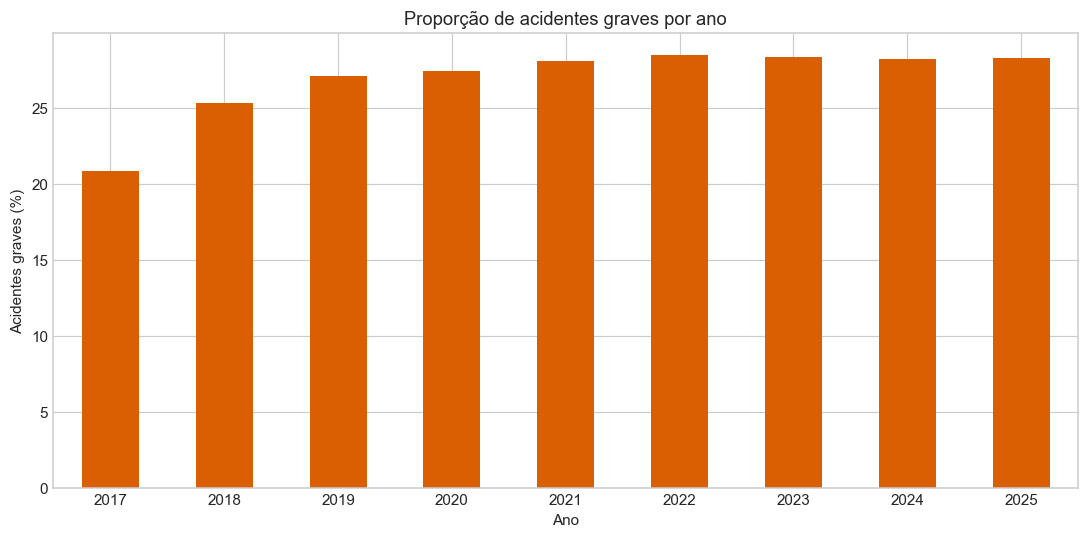

In [4]:
resumo_anual = dados.groupby("ano")["grave"].agg(["count", "sum", "mean"])
resumo_anual["grave_pct"] = resumo_anual["mean"] * 100
display(resumo_anual[["count", "sum", "grave_pct"]].round(2))

ax = resumo_anual["grave_pct"].plot(kind="bar", color="#d95f02")
ax.set(title="Proporção de acidentes graves por ano", xlabel="Ano", ylabel="Acidentes graves (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "01_gravidade_por_ano.png", bbox_inches="tight")
plt.show()

## 4. Preparação dos atributos

O cenário considerado começa após a comunicação inicial. Por isso, o tipo de acidente e a quantidade de veículos podem ser conhecidos. A causa declarada é excluída por poder depender de investigação posterior.

Não entram no modelo: mortos, feridos, pessoas, ilesos, classificação final, ID, delegacia ou unidade operacional. Município também é evitado por sua cardinalidade elevada; latitude, longitude, UF e BR já representam a localização.

In [5]:
X = preparar_atributos(dados)
y = dados["grave"]

qualidade = pd.DataFrame({
    "tipo": X.dtypes.astype(str),
    "ausentes": X.isna().sum(),
    "categorias": X.nunique(dropna=True),
})
display(qualidade)
assert list(X.columns) == ATRIBUTOS

,tipo,ausentes,categorias
dia_semana,string,0,7
uf,string,0,27
br,string,0,134
tipo_acidente,string,0,22
fase_dia,string,0,4
sentido_via,string,0,3
condicao_metereologica,string,0,10
tipo_pista,string,0,3
tracado_via,string,0,1328
uso_solo,string,0,2


## 5. Divisão por ano

- **Treino (2017–2023):** ajuste dos parâmetros dos modelos;
- **Validação (2024):** escolha do modelo e do limiar de decisão;
- **Teste (2025):** avaliação única, simulando aplicação em um ano futuro.

O teste não participa de nenhuma escolha.

In [6]:
mascara_treino = dados["ano"].isin(ANOS_TREINO)
mascara_validacao = dados["ano"].eq(ANO_VALIDACAO)
mascara_teste = dados["ano"].eq(ANO_TESTE)

X_treino, y_treino = X.loc[mascara_treino], y.loc[mascara_treino]
X_validacao, y_validacao = X.loc[mascara_validacao], y.loc[mascara_validacao]
X_teste, y_teste = X.loc[mascara_teste], y.loc[mascara_teste]

divisao = pd.DataFrame({
    "Conjunto": ["Treino", "Validação", "Teste"],
    "Anos": ["2017–2023", "2024", "2025"],
    "Linhas": [len(X_treino), len(X_validacao), len(X_teste)],
    "Graves_pct": [y_treino.mean() * 100, y_validacao.mean() * 100, y_teste.mean() * 100],
})
display(divisao.round(2))

,Conjunto,Anos,Linhas,Graves_pct
0,Treino,2017–2023,486982,26.22
1,Validação,2024,73156,28.19
2,Teste,2025,72529,28.25


## 6. Modelos

São comparados:

1. baseline que usa somente a prevalência do treino;
2. regressão logística com codificação one-hot;
3. Random Forest;
4. HistGradientBoosting com tratamento categórico.

Os modelos recebem pesos balanceados. Isso não altera a prevalência real, mas aumenta a atenção aos acidentes graves durante o ajuste.

In [7]:
preprocessamento_linear = ColumnTransformer([
    ("categoricas", OneHotEncoder(handle_unknown="ignore", min_frequency=50), COLUNAS_CATEGORICAS),
    ("numericas", Pipeline([
        ("imputacao", SimpleImputer(strategy="median")),
        ("escala", StandardScaler()),
    ]), COLUNAS_NUMERICAS),
])

preprocessamento_arvores = ColumnTransformer([
    ("categoricas", OrdinalEncoder(
        handle_unknown="use_encoded_value", unknown_value=-1,
        encoded_missing_value=-1, max_categories=200, min_frequency=20,
    ), COLUNAS_CATEGORICAS),
    ("numericas", SimpleImputer(strategy="median"), COLUNAS_NUMERICAS),
], verbose_feature_names_out=False)

mascara_categorica_transformada = (
    [True] * len(COLUNAS_CATEGORICAS) + [False] * len(COLUNAS_NUMERICAS)
)

modelos = {
    "Baseline": DummyClassifier(strategy="prior"),
    "Regressão Logística": Pipeline([
        ("preparo", preprocessamento_linear),
        ("modelo", LogisticRegression(
            max_iter=300, class_weight="balanced", solver="lbfgs"
        )),
    ]),
    "Random Forest": Pipeline([
        ("preparo", preprocessamento_arvores),
        ("modelo", RandomForestClassifier(
            n_estimators=180, max_depth=18, min_samples_leaf=15,
            max_features="sqrt", class_weight="balanced_subsample",
            random_state=SEED, n_jobs=-1,
        )),
    ]),
    "HistGradientBoosting": Pipeline([
        ("preparo", preprocessamento_arvores),
        ("modelo", HistGradientBoostingClassifier(
            max_iter=180, learning_rate=0.08, max_leaf_nodes=31,
            min_samples_leaf=40, l2_regularization=1.0,
            class_weight="balanced", categorical_features=mascara_categorica_transformada,
            random_state=SEED,
        )),
    ]),
}

tempos = {}
for nome, modelo in modelos.items():
    inicio = time.perf_counter()
    modelo.fit(X_treino, y_treino)
    tempos[nome] = time.perf_counter() - inicio
    print(f"{nome}: {tempos[nome]:.1f} s")

Baseline: 0.0 s


Regressão Logística: 16.7 s


Random Forest: 47.2 s


HistGradientBoosting: 13.2 s


## 7. Escolha na validação

A métrica principal é a área sob a curva precisão-recall (PR-AUC), adequada quando a classe positiva é menos frequente. Ela avalia as probabilidades em todos os limiares, sem escolher antecipadamente quantas ocorrências serão priorizadas.

In [8]:
prob_validacao = {}
linhas_validacao = []
for nome, modelo in modelos.items():
    prob = modelo.predict_proba(X_validacao)[:, 1]
    prob_validacao[nome] = prob
    linhas_validacao.append({
        "Modelo": nome,
        **metricas_probabilidade(y_validacao, prob),
        "Tempo_treino_s": tempos[nome],
    })

resultado_validacao = pd.DataFrame(linhas_validacao).sort_values("PR_AUC", ascending=False)
resultado_validacao.to_csv(PASTA_RESULTADOS / "metricas_validacao.csv", index=False)
display(resultado_validacao.round(4))

NOME_ESCOLHIDO = resultado_validacao.iloc[0]["Modelo"]
MODELO_ESCOLHIDO = modelos[NOME_ESCOLHIDO]
print(f"Modelo escolhido sem consultar 2025: {NOME_ESCOLHIDO}")

,Modelo,PR_AUC,ROC_AUC,Brier,Tempo_treino_s
3,HistGradientBoosting,0.5336,0.7151,0.2109,13.1678
2,Random Forest,0.5288,0.7109,0.2003,47.1995
1,Regressão Logística,0.5200,0.7055,0.2148,16.7059
0,Baseline,0.2819,0.5000,0.2028,0.0312


Modelo escolhido sem consultar 2025: HistGradientBoosting


### Calibração das probabilidades

Os modelos recebem pesos balanceados para dar atenção à classe grave. Isso melhora a separação, mas distorce a escala das probabilidades. Depois de escolher o modelo, aplicamos calibração sigmoide usando somente 2024. O teste de 2025 continua intocado.

A calibração preserva a ordenação avaliada pela PR-AUC; seu objetivo é reduzir o erro das probabilidades medido pelo Brier score.

In [9]:
calibrador = CalibratedClassifierCV(
    estimator=FrozenEstimator(MODELO_ESCOLHIDO), method="sigmoid"
)
calibrador.fit(X_validacao, y_validacao)
prob_validacao_calibrada = calibrador.predict_proba(X_validacao)[:, 1]

brier_antes = metricas_probabilidade(
    y_validacao, prob_validacao[NOME_ESCOLHIDO]
)["Brier"]
brier_depois = metricas_probabilidade(
    y_validacao, prob_validacao_calibrada
)["Brier"]
print(f"Brier antes da calibração: {brier_antes:.4f}")
print(f"Brier depois da calibração: {brier_depois:.4f}")

MODELO_FINAL = calibrador
prob_validacao[NOME_ESCOLHIDO] = prob_validacao_calibrada

Brier antes da calibração: 0.2109
Brier depois da calibração: 0.1739


### Limiar equilibrado

O limiar padrão de 0,5 nem sempre representa o melhor compromisso. Selecionamos em 2024 o limiar que maximiza o **F1**, equilibrando precisão e recall. Uma política diferente, orientada por capacidade operacional, será analisada separadamente ao priorizar as 20% ocorrências de maior probabilidade.

Limiar selecionado em 2024: 0.259
Precisão na validação: 0.424
Recall na validação: 0.650
F1 na validação: 0.513


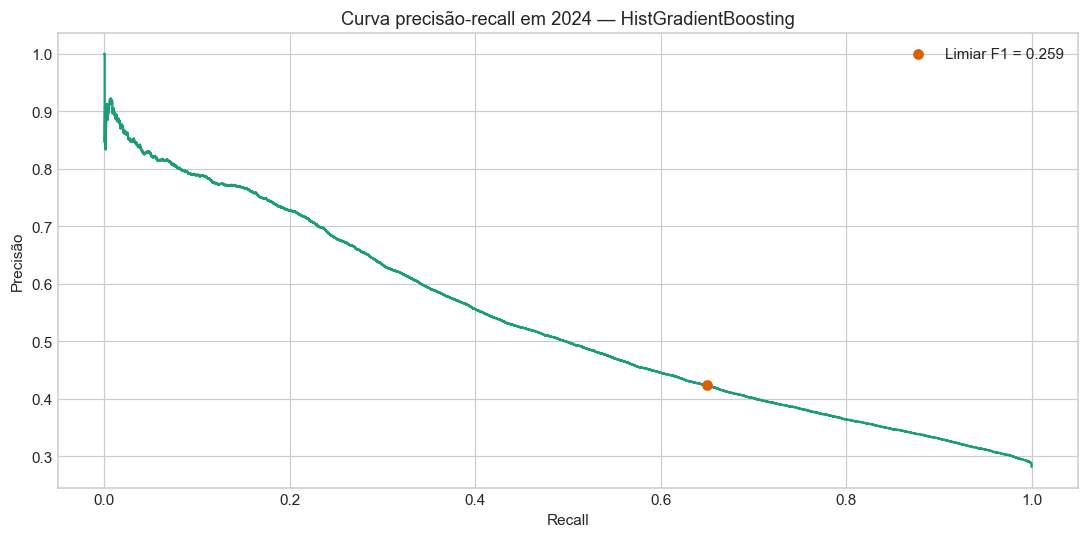

In [10]:
precisoes, recalls, limiares = precision_recall_curve(
    y_validacao, prob_validacao[NOME_ESCOLHIDO]
)
f1_valores = (2 * precisoes * recalls) / (precisoes + recalls + 1e-12)
indice_melhor = np.nanargmax(f1_valores[:-1])
LIMIAR_ESCOLHIDO, desempenho_limiar = selecionar_limiar_f1(
    y_validacao, prob_validacao[NOME_ESCOLHIDO]
)

print(f"Limiar selecionado em 2024: {LIMIAR_ESCOLHIDO:.3f}")
print(f"Precisão na validação: {desempenho_limiar['Precisao']:.3f}")
print(f"Recall na validação: {desempenho_limiar['Recall']:.3f}")
print(f"F1 na validação: {desempenho_limiar['F1']:.3f}")

fig, ax = plt.subplots()
ax.plot(recalls, precisoes, color="#1b9e77")
ax.scatter(recalls[indice_melhor], precisoes[indice_melhor], color="#d95f02", zorder=3,
           label=f"Limiar F1 = {LIMIAR_ESCOLHIDO:.3f}")
ax.set(title=f"Curva precisão-recall em 2024 — {NOME_ESCOLHIDO}",
       xlabel="Recall", ylabel="Precisão")
ax.legend()
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "02_curva_precisao_recall.png", bbox_inches="tight")
plt.show()

## 8. Avaliação final em 2025

O modelo e o limiar agora estão congelados. Além de PR-AUC e ROC-AUC, avaliamos precisão, recall, F1, F2, balanced accuracy e matriz de confusão.

In [11]:
prob_teste = {}
linhas_teste = []
for nome, modelo in modelos.items():
    estimador = MODELO_FINAL if nome == NOME_ESCOLHIDO else modelo
    prob = estimador.predict_proba(X_teste)[:, 1]
    prob_teste[nome] = prob
    limiar = LIMIAR_ESCOLHIDO if nome == NOME_ESCOLHIDO else 0.5
    linhas_teste.append({"Modelo": nome, **metricas_classificacao(y_teste, prob, limiar)})

resultado_teste = pd.DataFrame(linhas_teste).sort_values("PR_AUC", ascending=False)
resultado_teste.to_csv(PASTA_RESULTADOS / "metricas_teste.csv", index=False)
display(resultado_teste.round(4))

prob_escolhida = prob_teste[NOME_ESCOLHIDO]
pred_escolhida = (prob_escolhida >= LIMIAR_ESCOLHIDO).astype(int)
print(classification_report(y_teste, pred_escolhida, target_names=["Não grave", "Grave"]))

,Modelo,PR_AUC,ROC_AUC,Brier,Limiar,Acuracia,Balanced_accuracy,Precisao,Recall,F1,F2
3,HistGradientBoosting,0.5245,0.7108,0.1756,0.2593,0.6470,0.6463,0.4190,0.6447,0.5079,0.5820
2,Random Forest,0.5186,0.7046,0.2025,0.5000,0.7093,0.6426,0.4857,0.4893,0.4875,0.4886
1,Regressão Logística,0.5095,0.7003,0.2165,0.5000,0.6697,0.6410,0.4359,0.5749,0.4959,0.5405
0,Baseline,0.2825,0.5000,0.2031,0.5000,0.7175,0.5000,0.0000,0.0000,0.0000,0.0000


              precision    recall  f1-score   support

   Não grave       0.82      0.65      0.72     52036
       Grave       0.42      0.64      0.51     20493

    accuracy                           0.65     72529
   macro avg       0.62      0.65      0.62     72529
weighted avg       0.71      0.65      0.66     72529



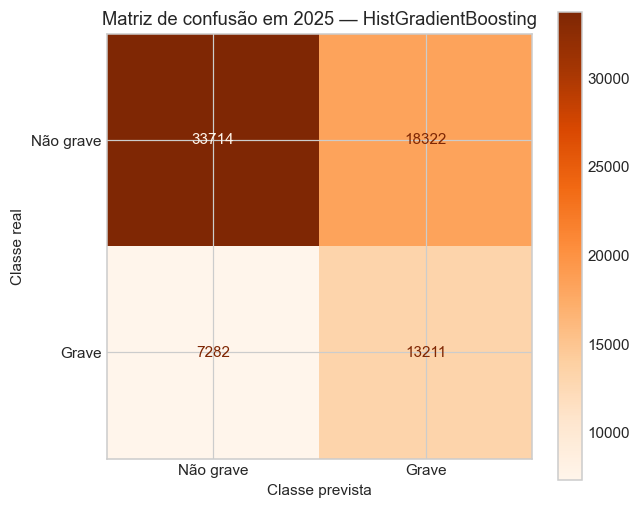

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_teste, pred_escolhida, display_labels=["Não grave", "Grave"],
    cmap="Oranges", values_format="d", ax=ax,
)
ax.set_title(f"Matriz de confusão em 2025 — {NOME_ESCOLHIDO}")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "03_matriz_confusao.png", bbox_inches="tight")
plt.show()

### Incerteza das métricas

Uma métrica pontual muda com a amostra. Estimamos intervalos de confiança de 95% por bootstrap das ocorrências de 2025. Essa análise quantifica incerteza amostral, mas não cobre mudanças futuras de distribuição.

In [13]:
ic_pr_auc = intervalo_bootstrap(
    y_teste, prob_escolhida, average_precision_score, repeticoes=400
)
ic_roc_auc = intervalo_bootstrap(
    y_teste, prob_escolhida, roc_auc_score, repeticoes=400
)
ic_f1 = intervalo_bootstrap(
    y_teste, prob_escolhida,
    lambda y, p: f1_score(y, p >= LIMIAR_ESCOLHIDO), repeticoes=400,
)

intervalos = pd.DataFrame([
    {
        "Metrica": "PR-AUC",
        "Estimativa": average_precision_score(y_teste, prob_escolhida),
        "IC95_inferior": ic_pr_auc[0],
        "IC95_superior": ic_pr_auc[1],
    },
    {
        "Metrica": "ROC-AUC",
        "Estimativa": roc_auc_score(y_teste, prob_escolhida),
        "IC95_inferior": ic_roc_auc[0],
        "IC95_superior": ic_roc_auc[1],
    },
    {
        "Metrica": "F1",
        "Estimativa": f1_score(y_teste, pred_escolhida),
        "IC95_inferior": ic_f1[0],
        "IC95_superior": ic_f1[1],
    },
])
intervalos.to_csv(PASTA_RESULTADOS / "intervalos_confianca.csv", index=False)
display(intervalos.round(4))

,Metrica,Estimativa,IC95_inferior,IC95_superior
0,PR-AUC,0.5245,0.5173,0.5317
1,ROC-AUC,0.7108,0.7070,0.7151
2,F1,0.5079,0.5029,0.5129


## 9. Cenário operacional: priorizar 20% das ocorrências

Ordenamos as ocorrências de 2025 pela probabilidade prevista. O objetivo é responder uma pergunta operacional simples:

> Se somente 20% das ocorrências pudessem receber prioridade máxima, qual proporção dos acidentes graves estaria nesse grupo?

Uma ordenação aleatória capturaria aproximadamente 20% dos graves.

Graves capturados nos 20% prioritários: 39.0%
Precisão dentro do grupo prioritário: 55.1%
Lift em relação à prevalência: 1.95x


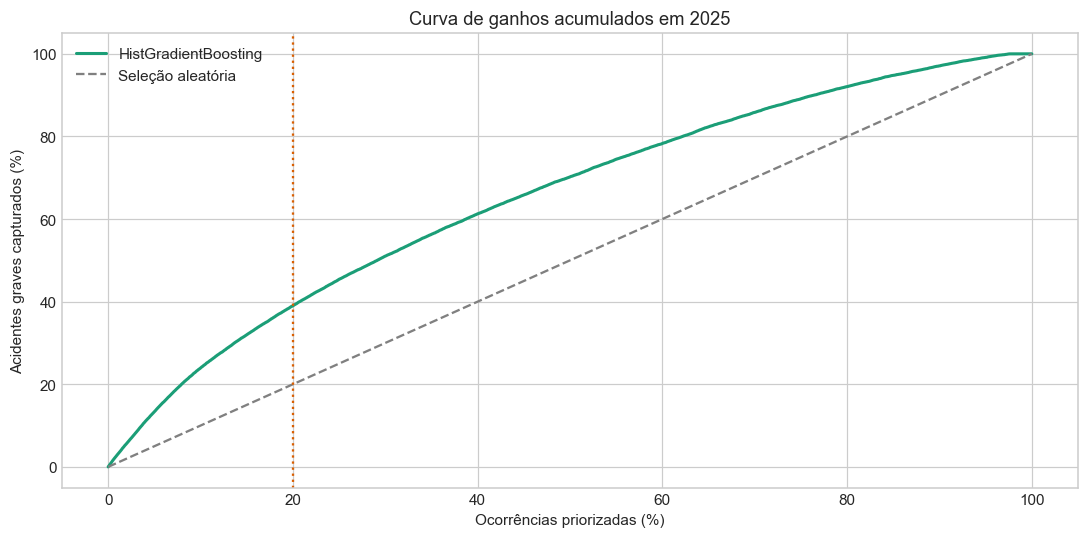

In [14]:
ordem = np.argsort(-prob_escolhida)
y_ordenado = y_teste.to_numpy()[ordem]
fracao_ocorrencias = np.arange(1, len(y_ordenado) + 1) / len(y_ordenado)
fracao_graves_capturados = np.cumsum(y_ordenado) / y_ordenado.sum()

priorizacao_20 = avaliar_priorizacao(y_teste, prob_escolhida, fracao=0.20)
recall_top20 = priorizacao_20["Recall"]
precisao_top20 = priorizacao_20["Precisao"]
lift_top20 = priorizacao_20["Lift"]

print(f"Graves capturados nos 20% prioritários: {recall_top20 * 100:.1f}%")
print(f"Precisão dentro do grupo prioritário: {precisao_top20 * 100:.1f}%")
print(f"Lift em relação à prevalência: {lift_top20:.2f}x")

fig, ax = plt.subplots()
ax.plot(fracao_ocorrencias * 100, fracao_graves_capturados * 100,
        label=NOME_ESCOLHIDO, color="#1b9e77", linewidth=2)
ax.plot([0, 100], [0, 100], "--", label="Seleção aleatória", color="gray")
ax.axvline(20, color="#d95f02", linestyle=":")
ax.set(title="Curva de ganhos acumulados em 2025",
       xlabel="Ocorrências priorizadas (%)", ylabel="Acidentes graves capturados (%)")
ax.legend()
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "04_ganhos_acumulados.png", bbox_inches="tight")
plt.show()

## 10. Importância das variáveis

Usamos importância por permutação em uma amostra de 20 mil registros de 2025. Cada coluna é embaralhada e medimos a queda na PR-AUC. Isso indica associação preditiva e dependência do modelo, não relação causal.

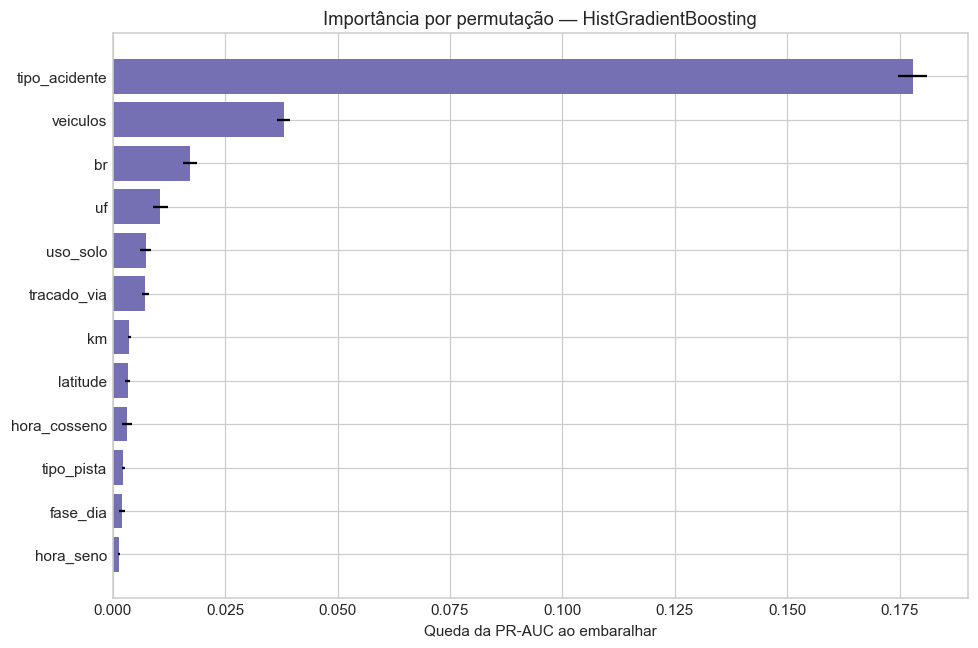

,Atributo,Importancia_media,Desvio
3,tipo_acidente,0.1779,0.0032
11,veiculos,0.0380,0.0016
2,br,0.0172,0.0015
1,uf,0.0106,0.0016
9,uso_solo,0.0074,0.0012
8,tracado_via,0.0073,0.0008
10,km,0.0038,0.0004
12,latitude,0.0034,0.0006
15,hora_cosseno,0.0031,0.0011
7,tipo_pista,0.0024,0.0003


In [15]:
amostra_teste = X_teste.sample(n=min(20_000, len(X_teste)), random_state=SEED)
y_amostra = y_teste.loc[amostra_teste.index]

resultado_importancia = permutation_importance(
    MODELO_FINAL, amostra_teste, y_amostra,
    scoring="average_precision", n_repeats=5, random_state=SEED, n_jobs=1,
)
importancias = pd.DataFrame({
    "Atributo": ATRIBUTOS,
    "Importancia_media": resultado_importancia.importances_mean,
    "Desvio": resultado_importancia.importances_std,
}).sort_values("Importancia_media", ascending=False)
importancias.to_csv(PASTA_RESULTADOS / "importancia_atributos.csv", index=False)

top = importancias.head(12).sort_values("Importancia_media")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["Atributo"], top["Importancia_media"], xerr=top["Desvio"], color="#7570b3")
ax.set(title=f"Importância por permutação — {NOME_ESCOLHIDO}",
       xlabel="Queda da PR-AUC ao embaralhar")
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "05_importancia_atributos.png", bbox_inches="tight")
plt.show()
display(importancias.head(12).round(4))

### Estudo de ablação: sem informações da dinâmica

O tipo do acidente e a quantidade de veículos só existem depois que a ocorrência é comunicada. Para medir a dependência dessas informações, treinamos uma versão do mesmo algoritmo sem essas duas colunas. A diferença de PR-AUC delimita quanto do desempenho vem da dinâmica inicial do acidente.

In [16]:
categoricas_contexto = [c for c in COLUNAS_CATEGORICAS if c != "tipo_acidente"]
numericas_contexto = [c for c in COLUNAS_NUMERICAS if c != "veiculos"]
atributos_contexto = categoricas_contexto + numericas_contexto

preparo_contexto = ColumnTransformer([
    ("categoricas", OrdinalEncoder(
        handle_unknown="use_encoded_value", unknown_value=-1,
        encoded_missing_value=-1, max_categories=200, min_frequency=20,
    ), categoricas_contexto),
    ("numericas", SimpleImputer(strategy="median"), numericas_contexto),
], verbose_feature_names_out=False)

mascara_contexto = [True] * len(categoricas_contexto) + [False] * len(numericas_contexto)
modelo_contexto = Pipeline([
    ("preparo", preparo_contexto),
    ("modelo", HistGradientBoostingClassifier(
        max_iter=180, learning_rate=0.08, max_leaf_nodes=31,
        min_samples_leaf=40, l2_regularization=1.0,
        class_weight="balanced", categorical_features=mascara_contexto,
        random_state=SEED,
    )),
])
modelo_contexto.fit(X_treino[atributos_contexto], y_treino)
prob_contexto = modelo_contexto.predict_proba(X_teste[atributos_contexto])[:, 1]

ablacao = pd.DataFrame([
    {
        "Cenario": "Atendimento inicial completo",
        "PR_AUC": average_precision_score(y_teste, prob_escolhida),
        "ROC_AUC": roc_auc_score(y_teste, prob_escolhida),
    },
    {
        "Cenario": "Sem tipo do acidente e veículos",
        "PR_AUC": average_precision_score(y_teste, prob_contexto),
        "ROC_AUC": roc_auc_score(y_teste, prob_contexto),
    },
])
ablacao["Queda_PR_AUC_pct"] = (
    1 - ablacao["PR_AUC"] / ablacao.iloc[0]["PR_AUC"]
) * 100
ablacao.to_csv(PASTA_RESULTADOS / "estudo_ablacao.csv", index=False)
display(ablacao.round(4))

,Cenario,PR_AUC,ROC_AUC,Queda_PR_AUC_pct
0,Atendimento inicial completo,0.5245,0.7108,0.000
1,Sem tipo do acidente e veículos,0.3963,0.6285,24.445


## 11. Calibração e análise de erros

Uma probabilidade de 0,7 deveria corresponder aproximadamente a 70% de acidentes graves entre casos semelhantes. A calibração é relevante quando a saída é usada para priorizar recursos.

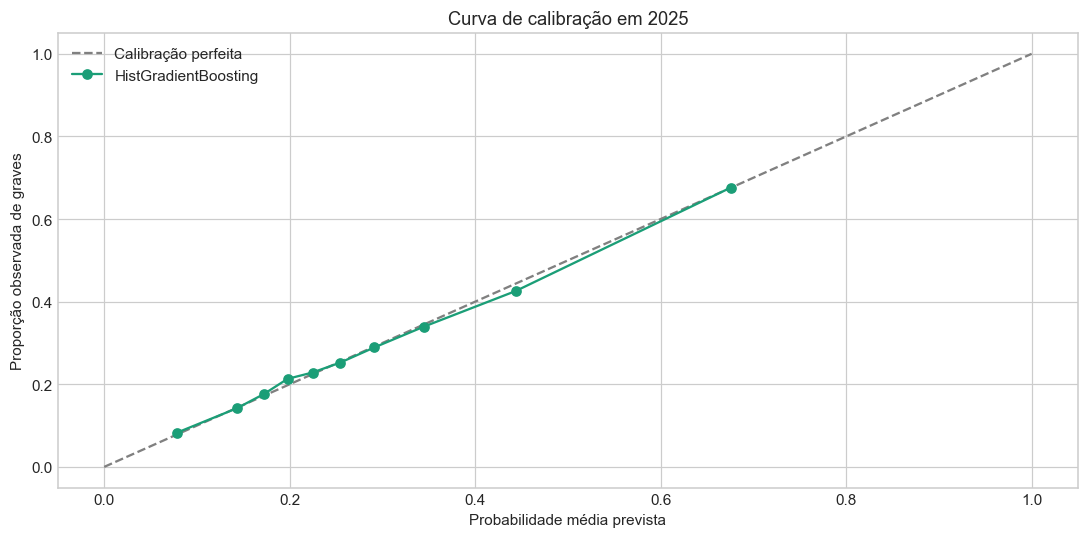

,ocorrencias,graves,recall
fase_dia,,,
Pleno dia,40375.0,10280.0,0.544
Anoitecer,3926.0,1102.0,0.689
Amanhecer,3447.0,1063.0,0.726
Plena Noite,24781.0,8048.0,0.756


,ocorrencias,graves,recall
tipo_pista,,,
Múltipla,7014.0,1550.0,0.401
Dupla,30782.0,7338.0,0.454
Simples,34733.0,11605.0,0.798


In [17]:
fracoes_positivas, medias_previstas = calibration_curve(
    y_teste, prob_escolhida, n_bins=10, strategy="quantile"
)
fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], "--", color="gray", label="Calibração perfeita")
ax.plot(medias_previstas, fracoes_positivas, marker="o", color="#1b9e77", label=NOME_ESCOLHIDO)
ax.set(title="Curva de calibração em 2025", xlabel="Probabilidade média prevista",
       ylabel="Proporção observada de graves")
ax.legend()
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "06_calibracao.png", bbox_inches="tight")
plt.show()

analise = dados.loc[mascara_teste, ["fase_dia", "tipo_pista", "condicao_metereologica"]].copy()
analise["real"] = y_teste.to_numpy()
analise["previsto"] = pred_escolhida

def recall_por_grupo(coluna, minimo=300):
    tabela = analise.groupby(coluna).apply(
        lambda g: pd.Series({
            "ocorrencias": len(g),
            "graves": g["real"].sum(),
            "recall": recall_score(g["real"], g["previsto"], zero_division=0),
        }), include_groups=False,
    )
    return tabela[tabela["ocorrencias"] >= minimo].sort_values("recall")

display(recall_por_grupo("fase_dia").round(3))
display(recall_por_grupo("tipo_pista").round(3))

## 12. Resumo para o relatório

A célula imprime os valores que devem ser transcritos. Um resultado forte exige mais que acurácia: compare PR-AUC com a prevalência, examine recall e falsos negativos e avalie a concentração de graves no grupo prioritário.

In [18]:
linha_final = resultado_teste.loc[resultado_teste["Modelo"] == NOME_ESCOLHIDO].iloc[0]
print("RESUMO PARA O RELATÓRIO")
print("-" * 65)
print(f"Ocorrências totais: {len(dados):,}")
print(f"Treino: {len(X_treino):,} | Validação: {len(X_validacao):,} | Teste: {len(X_teste):,}")
print(f"Prevalência de graves em 2025: {y_teste.mean() * 100:.2f}%")
print(f"Modelo selecionado em 2024: {NOME_ESCOLHIDO}")
print(f"Limiar selecionado em 2024: {LIMIAR_ESCOLHIDO:.3f}")
print(f"PR-AUC em 2025: {linha_final['PR_AUC']:.3f}")
print(f"IC95% da PR-AUC: [{ic_pr_auc[0]:.3f}, {ic_pr_auc[1]:.3f}]")
print(f"ROC-AUC em 2025: {linha_final['ROC_AUC']:.3f}")
print(f"Brier calibrado em 2025: {linha_final['Brier']:.3f}")
print(f"Precisão em 2025: {linha_final['Precisao']:.3f}")
print(f"Recall em 2025: {linha_final['Recall']:.3f}")
print(f"F1 em 2025: {linha_final['F1']:.3f}")
print(f"F2 em 2025: {linha_final['F2']:.3f}")
print(f"Graves capturados no top 20%: {recall_top20 * 100:.1f}%")
print(f"Lift no top 20%: {lift_top20:.2f}x")
print(f"PR-AUC sem tipo do acidente e veículos: {ablacao.iloc[1]['PR_AUC']:.3f}")

RESUMO PARA O RELATÓRIO
-----------------------------------------------------------------
Ocorrências totais: 632,667
Treino: 486,982 | Validação: 73,156 | Teste: 72,529
Prevalência de graves em 2025: 28.25%
Modelo selecionado em 2024: HistGradientBoosting
Limiar selecionado em 2024: 0.259
PR-AUC em 2025: 0.524
IC95% da PR-AUC: [0.517, 0.532]
ROC-AUC em 2025: 0.711
Brier calibrado em 2025: 0.176
Precisão em 2025: 0.419
Recall em 2025: 0.645
F1 em 2025: 0.508
F2 em 2025: 0.582
Graves capturados no top 20%: 39.0%
Lift no top 20%: 1.95x
PR-AUC sem tipo do acidente e veículos: 0.396


## 13. Limitações

1. O banco contém acidentes atendidos e registrados pela PRF, não todos os deslocamentos nas rodovias.
2. Sem volume de tráfego, não se calcula taxa de risco por veículo-quilômetro.
3. O tipo do acidente e o número de veículos pressupõem que a ocorrência já foi comunicada.
4. O alvo depende do registro de feridos graves e mortes no BAT.
5. Probabilidade não substitui protocolos de atendimento.
6. Importância preditiva não demonstra causalidade nem recomenda automaticamente uma intervenção.
7. Desempenho pode variar entre regiões e grupos, por isso os falsos negativos devem ser examinados.

Como trabalho futuro, seria possível integrar volume de tráfego, geometria detalhada da rodovia, distância até hospitais e dados meteorológicos externos, além de avaliar calibração por estado.